<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Statistics%20/Descriptive_Stat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
!pip install opendatasets

In [72]:
import opendatasets as od

In [73]:
od.download("https://www.kaggle.com/datasets/hesh97/titanicdataset-traincsv")

Skipping, found downloaded files in "./titanicdataset-traincsv" (use force=True to force download)


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


In [75]:
df = pd.read_csv("/content/titanicdataset-traincsv/train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#Univariate

1.catagorical

In [76]:
#frequency distribution table


In [77]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [78]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


#bar chart

<Axes: xlabel='Pclass'>

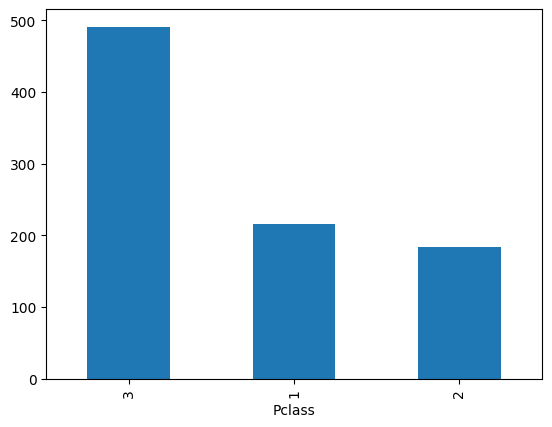

In [79]:
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

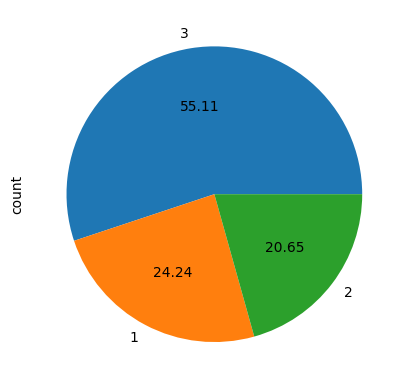

In [80]:
df['Pclass'].value_counts().plot(kind='pie', autopct = '%0.2f')

# Cumulative Frequency

In [81]:
a = df['Pclass'].value_counts()

In [82]:
a

,count
Pclass,
3,491
1,216
2,184


In [83]:
(a/a.sum())*100

,count
Pclass,
3,55.106622
1,24.242424
2,20.650954


In [84]:
b = ((a/a.sum())*100).values
b

array([55.10662177, 24.24242424, 20.65095398])

In [85]:
c = []
cf = 0
for i in b:
  cf = cf + i
  c.append(cf)


In [86]:
c

[np.float64(55.106621773288445),
 np.float64(79.34904601571269),
 np.float64(100.0)]

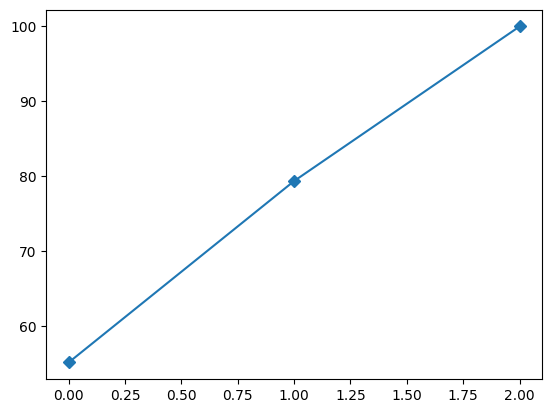

In [87]:
plt.plot(c, marker = 'D')

#Numerical data

# Histograms


In [88]:
d = df['Age'].values

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

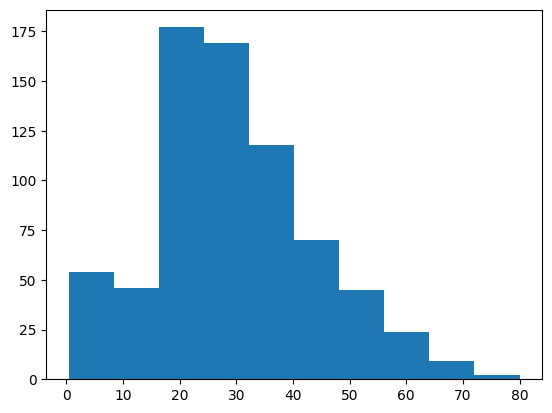

In [89]:
plt.hist(d)

# BoxPlot

<Axes: xlabel='Age'>

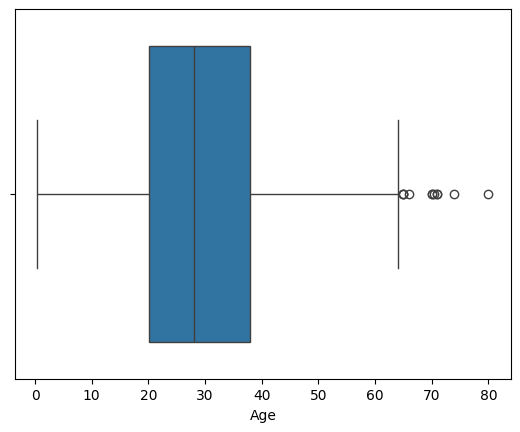

In [90]:
sb.boxplot(x = 'Age', data = df)

In [91]:
a = df.dropna(subset=['Age'])
a = a['Age'].values

np.median(a)

np.float64(28.0)

# kdeplot

<Axes: xlabel='Age', ylabel='Density'>

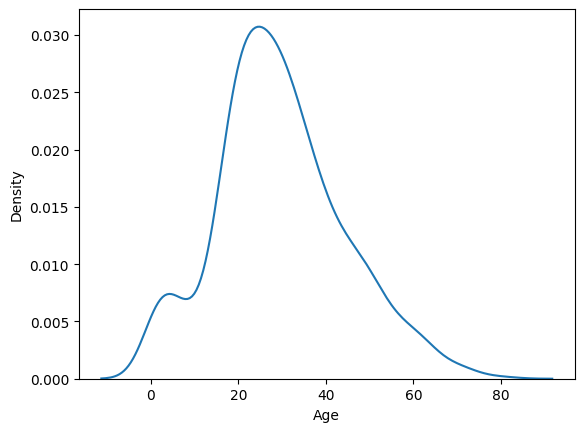

In [92]:
sb.kdeplot(df['Age'])

# Working with 2 variable / data (Bivariate Analysis)

#1. Catagorical Vs Numerical

 a.Box Plot

<Axes: xlabel='Pclass', ylabel='Age'>

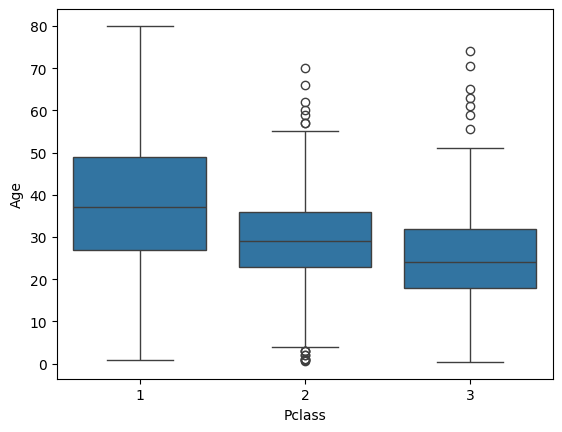

In [93]:
sb.boxplot(y = df['Age'], x = df['Pclass'], data = df)

In [94]:
# df['Pclass'].value_counts().values~

b. Bar Plot

<Axes: xlabel='Pclass', ylabel='Age'>

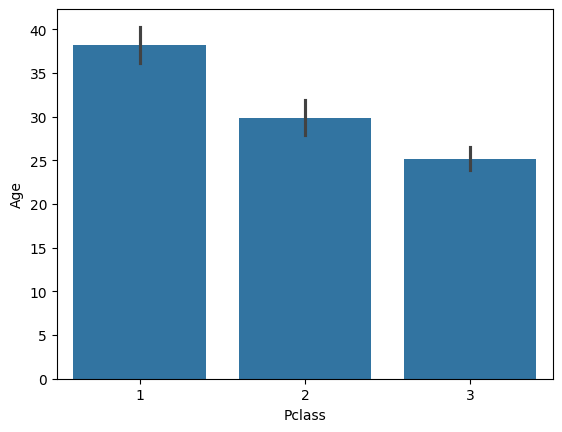

In [95]:
sb.barplot(x = df['Pclass'], y = df['Age'], data = df)

# Numerical Vs Numerical

In [96]:
#scatter plot

In [97]:
df['Fare']

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


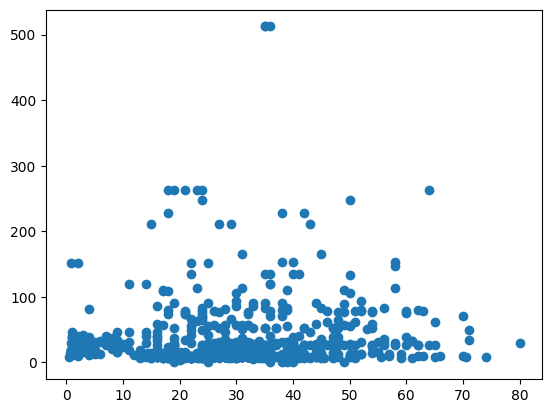

In [98]:
a = df['Age']
b = df['Fare']

plt.scatter(a, b)

# Categorical Vs Categorical

In [99]:
# Cross table/ Contingency Table
pd.crosstab(df['Pclass'], df['Sex'])

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


<Axes: xlabel='Pclass'>

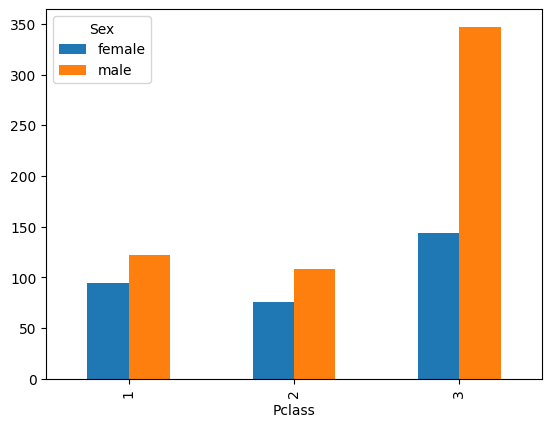

In [101]:
# Side by side bar chart
pd.crosstab(df['Pclass'], df['Sex']).plot(kind = 'bar')

<Axes: xlabel='Sex', ylabel='Pclass'>

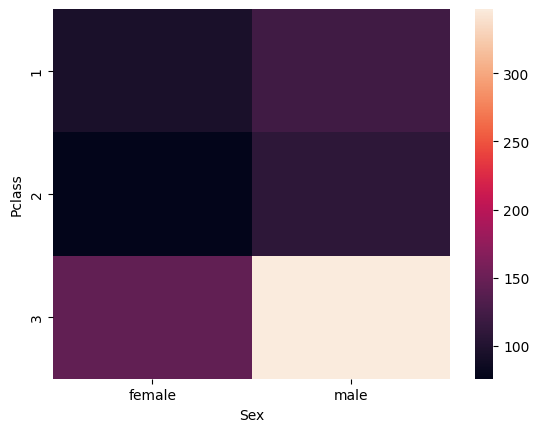

In [104]:
#heatmap
ct = pd.crosstab(df['Pclass'], df['Sex'])
sb.heatmap(ct)